# Data exploration — the datasets we EVALUATE on

These 21 datasets are what every model is **scored** on. They are not training data and
they are not priors: this notebook is about the measurement instrument, not the method.

Three questions it answers:

| question | why it decides something |
|---|---|
| **How much boundary mass does each LGD target have?** | Where it is large, a model that only predicts smooth interior values cannot be calibrated — it can get the average right while being wrong about every individual loan. |
| **How rare is default in each PD dataset?** | Sets the imbalance the models must handle, and shows how far real data sits from a balanced prior. |
| **What shape, types and missingness?** | Sets the ranges the prior samples over, and flags anything that would undermine a published number. |

Everything reads the **processed parquet cache** through `src.data.pipeline`, so this
notebook sees exactly the tables the evaluation sees — not a separate re-read of the raw
CSVs that might disagree. Anything not yet processed is processed on first access, which
takes a few minutes the first time.

All plots live in `src/visualize/data_plots.py`. **Ends with a copy-pasteable text
summary.**

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from src.visualize import data_plots, figures, style, summaries

style.use_style()   # ONE shared style: identical colours in every notebook
pd.set_option("display.width", 220, "display.max_columns", 60, "display.max_rows", 60)

# Clears THIS notebook's figure folder — and no other — BEFORE anything is
# drawn, then saves every figure as PDF (print) + PNG (committable). Identical
# behaviour in Jupyter and under scripts/run_notebooks.py.
FIGS = figures.for_notebook("data_exploration")

## 1. Load everything

A dataset that cannot be read is **skipped with a message** rather than killing the
notebook — one bad raw file should not stop you looking at the other twenty.

In [2]:
lgd = data_plots.load_all("lgd")
pd_ = data_plots.load_all("pd")
both = {"lgd": lgd, "pd": pd_}
print(f"\nloaded {len(lgd)} LGD and {len(pd_)} PD datasets")


loaded 7 LGD and 14 PD datasets


## 2. LGD — the boundary-mass story

Read **`boundary mass`** and **`in [0,1]`** first. `boundary mass` is the fraction of rows
sitting exactly at the minimum or maximum.

In [3]:
data_plots.summary_table(lgd, 'lgd')

,dataset,rows,features,categorical,% categorical,missing %,mass at 0,mass at 1,boundary mass,mean,"in [0,1]"
0,0001.heloc,58862,9,0,0.0,3.47,0.2156,0.5147,0.7302,0.7069,True
1,0006.lgd_freddie,16002,20,8,40.0,1.17,0.1142,0.0807,0.1949,0.4588,True
2,0007.lgd_lendingclub,5627,17,7,41.2,0.07,0.0148,0.0032,0.0179,0.5905,True
3,0002.loss2,4637,52,23,44.2,2.70,0.0362,0.0371,0.0733,0.3920,True
4,0003.axa,2545,2,0,0.0,0.00,0.2861,0.0562,0.3422,0.2281,True
5,0004.base_model,762,202,88,43.6,8.79,0.1050,0.1194,0.2244,0.3234,True
6,0005.base_modelisation,594,256,77,30.1,0.70,0.1162,0.1599,0.2761,0.3301,True


### 2a. Every LGD target, one panel each

The motivating figure of the project. Compare the two end bars against the middle.
Dashed red lines mark exact atoms — in a 40-bin histogram, an atom at 0 and a cluster at
0.02 look identical, and only one of them is the point.

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


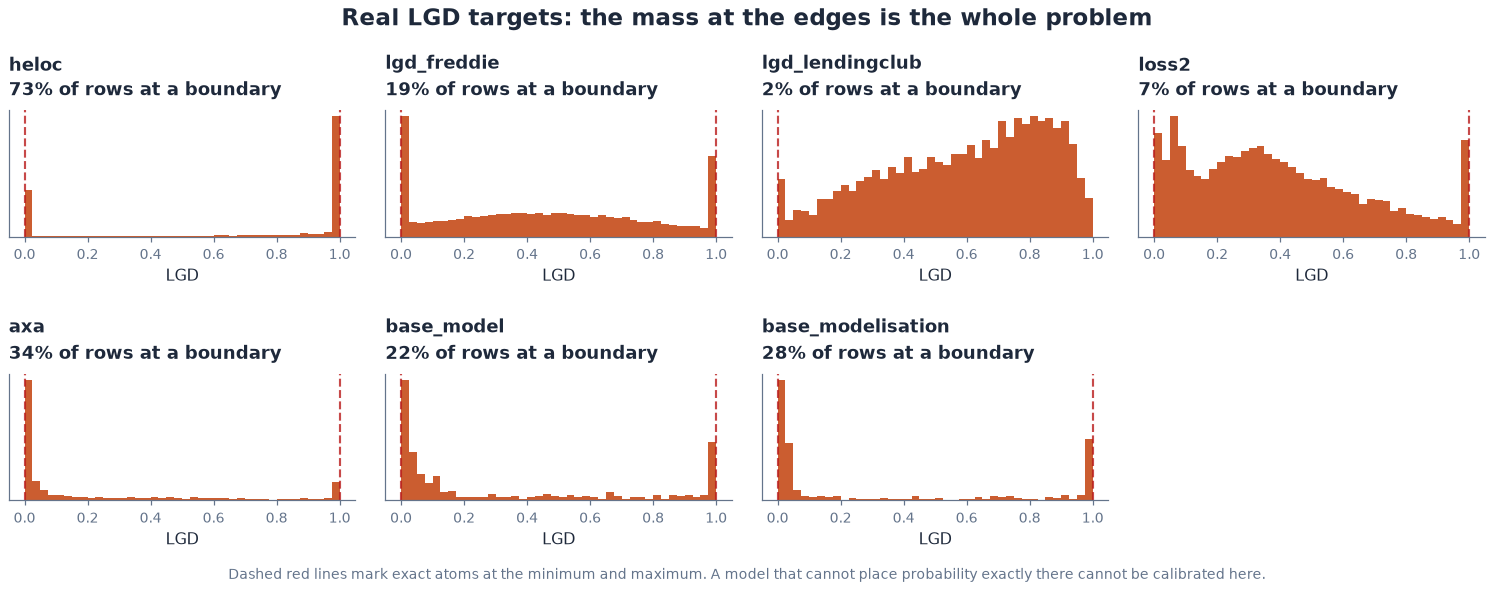

In [4]:
FIGS.save(data_plots.plot_lgd_targets(lgd), "lgd_targets");

### 2b. Which datasets does it actually matter for?

A ranked list, because that is the practical question. Two things to take away: the
spread is **wide** (so the prior needs a range, not a value), and mass at 0 and at 1 are
**not symmetric** (so the prior samples them separately).

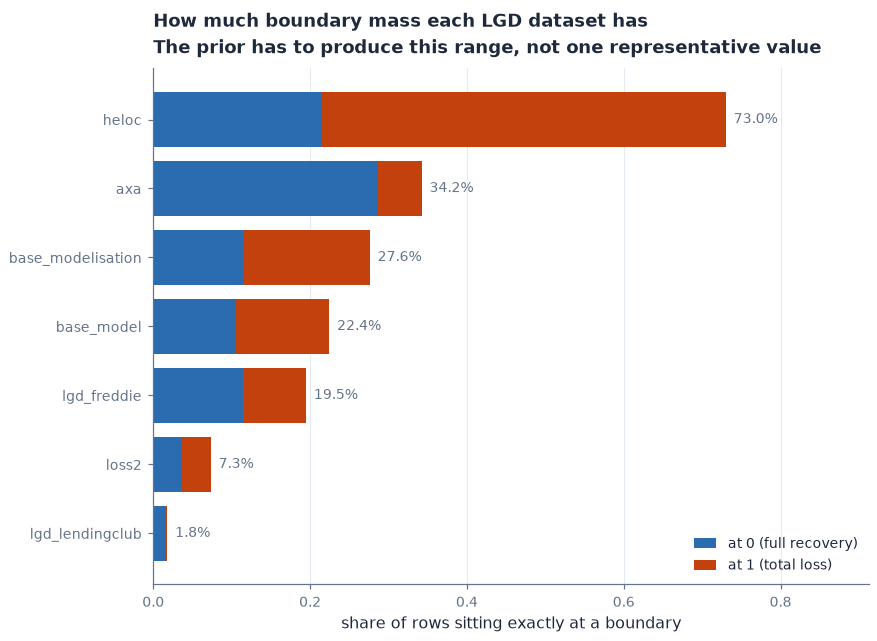

In [5]:
FIGS.save(data_plots.plot_boundary_mass_ranking(lgd), "boundary_mass_ranking");

## 3. PD — the imbalance story

`imbalance 1:n` restates the base rate as odds, which is easier to feel: 1:99 means one
default per hundred loans.

In [6]:
data_plots.summary_table(pd_, 'pd')

,dataset,rows,features,categorical,% categorical,missing %,base rate,imbalance 1:n,n positive
0,0006.hackerearth,532428,37,2,5.4,6.53,0.2363,3.2,125827
1,0012.home_credit,307511,120,16,13.3,22.73,0.0807,11.4,24825
2,0003.vehicle_loan,233154,33,1,3.0,0.00,0.2171,3.6,50611
3,0014.algorithmwatch,158700,2986,0,0.0,0.00,0.3781,1.6,60003
4,0001.gmsc,150000,10,0,0.0,2.24,0.0668,14.0,10026
5,0011.loan_default,105471,759,0,0.0,0.98,0.0928,9.8,9783
6,0009.bank_status,100000,16,0,0.0,6.09,0.2264,3.4,22639
7,0007.cobranded,80000,47,0,0.0,18.84,0.2462,3.1,19697
8,0002.taiwan_creditcard,30000,23,0,0.0,0.00,0.2212,3.5,6636
9,0004.lendingclub,9578,13,1,7.7,0.00,0.1601,5.2,1533


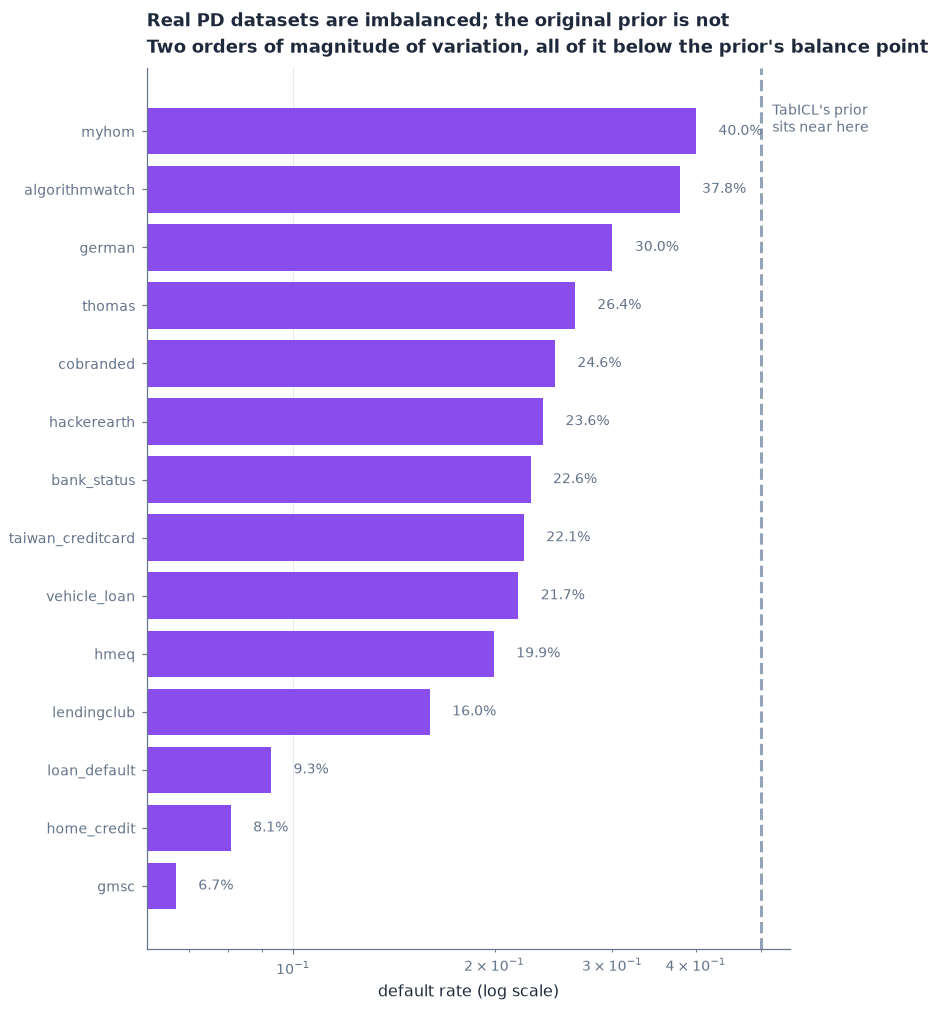

In [7]:
FIGS.save(data_plots.plot_pd_base_rates(pd_), "pd_base_rates");

Log axis, because the rates span two orders of magnitude; on a linear axis every dataset
below 5% collapses into the same sliver.

The dashed grey line is roughly where TabICL's prior sits. **Every real dataset is to the
left of it.**

## 4. Shape, types and missingness

If the prior generated 500-column tables and every real dataset had 20, the extra
capacity would be wasted; if it generated 200-row tables and real ones have a million, it
would never learn to use a long context.

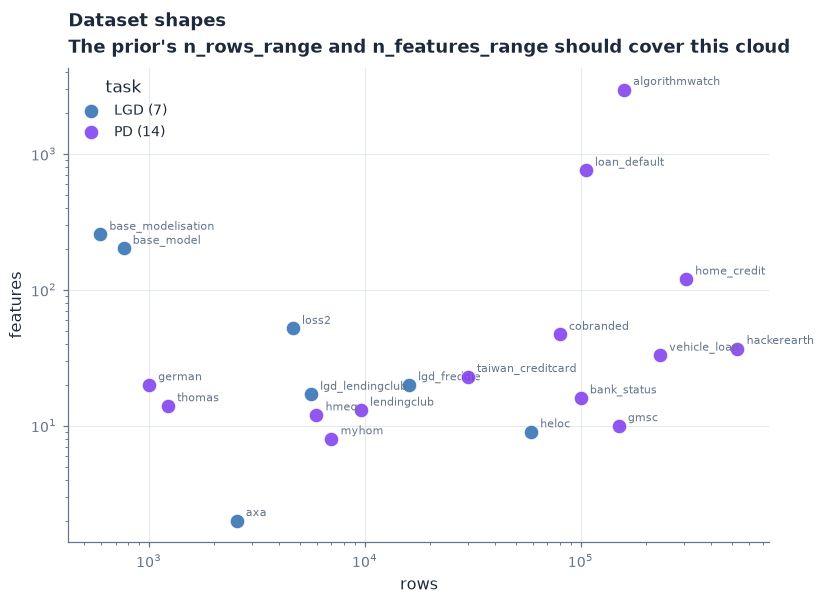

In [8]:
FIGS.save(data_plots.plot_shapes(both), "shapes");

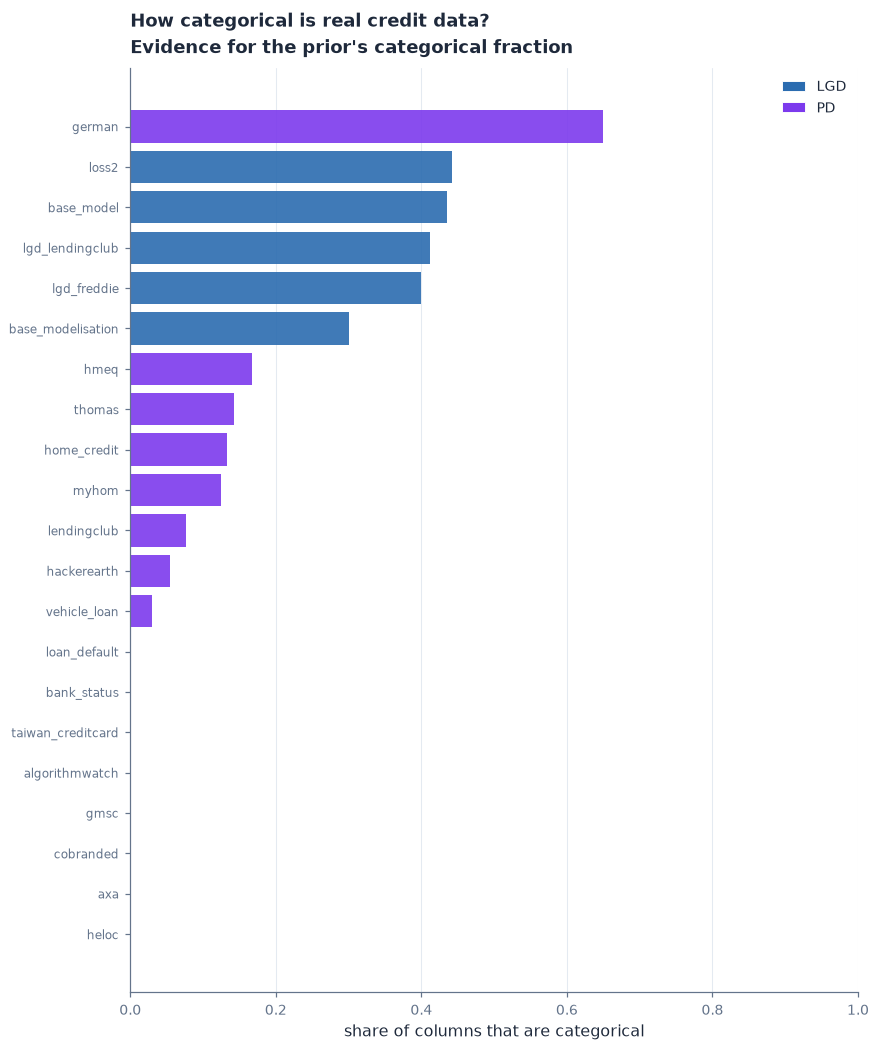

In [9]:
FIGS.save(data_plots.plot_type_mix(both), "type_mix");

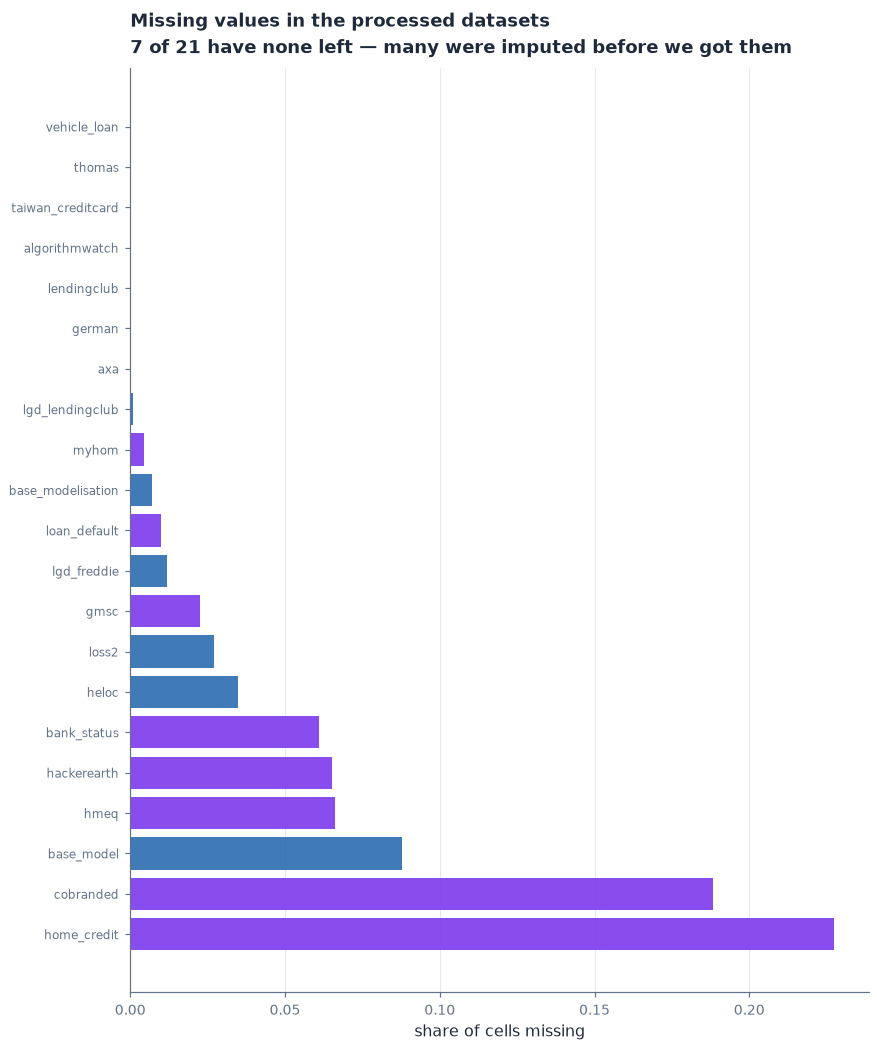

In [10]:
FIGS.save(data_plots.plot_missingness(both), "missingness");

Note how many datasets have **zero** missing values: most were imputed before we received
them, so real missingness is understated here. Our prior still injects missingness as an
explicit mechanism — a model that has never seen a NaN handles one badly — but these
numbers measure the upstream pipeline, not the domain, so do not tune to them.

## 5. Feature dependence

Real credit data comes in **blocks** of strongly correlated columns: several measures of
the same balance, several vintages of the same delinquency count. Our prior builds
features through random DAGs precisely so those blocks appear. If these heatmaps were
diagonal, that design choice would be wrong.

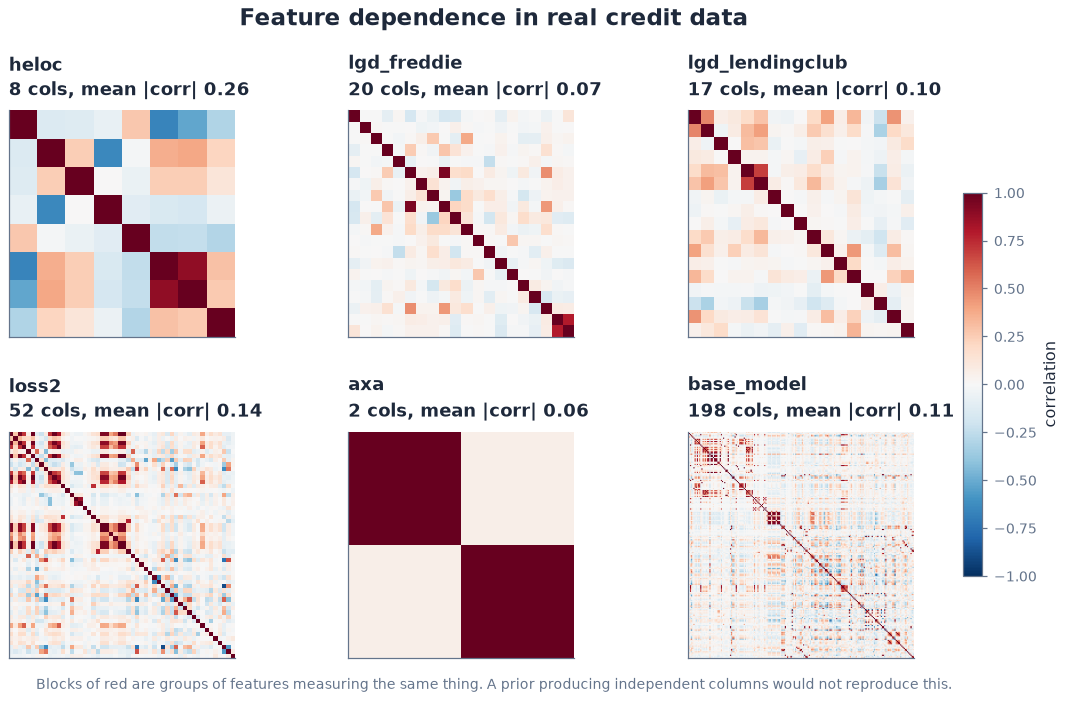

In [11]:
FIGS.save(data_plots.plot_feature_correlations(lgd, n_show=6), "feature_correlations_lgd");

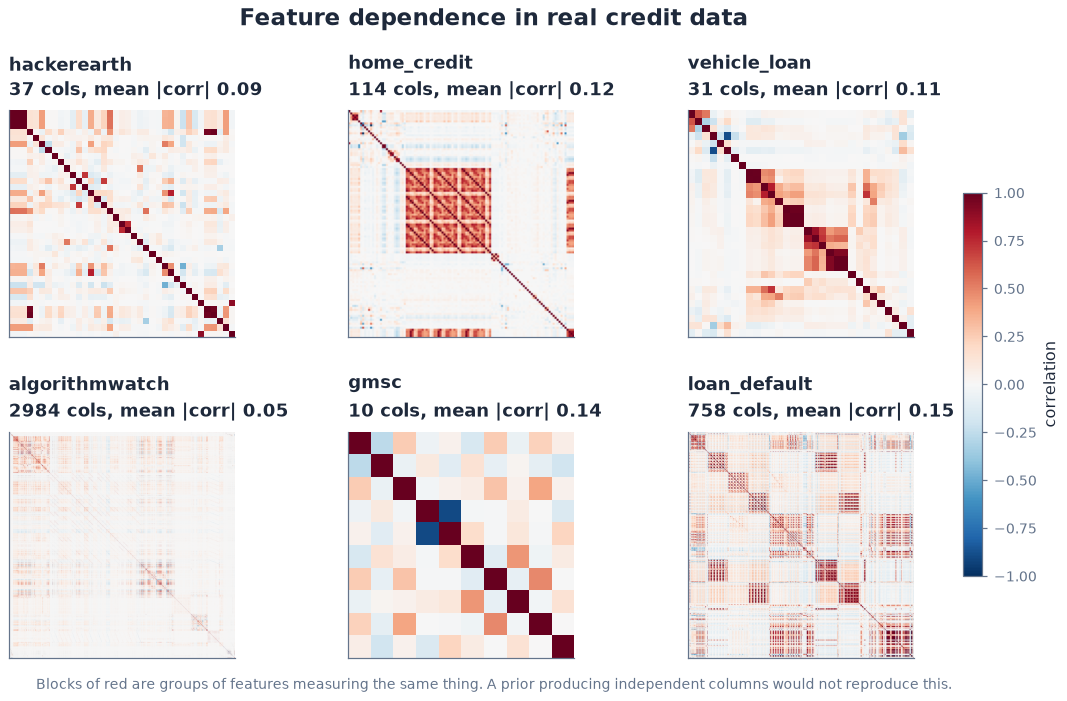

In [12]:
FIGS.save(data_plots.plot_feature_correlations(pd_, n_show=6), "feature_correlations_pd");

## 6. Leakage screen

For every column, its absolute correlation with the target. This exists because
`lgd_lendingclub` gives R² around 0.71–0.76 — far above anything reported for LGD
modelling, which usually means a column encodes the answer.

A high correlation is a **pointer, not proof**: a single strong predictor can be
legitimate. And this only looks at one feature at a time, so it cannot see leakage spread
across several columns.

In [13]:
leak_lgd = data_plots.leakage_check(lgd, "lgd")
leak_lgd.head(12)

,dataset,feature,|corr with target|,suspicious
0,0007.lgd_lendingclub,months_since_origination,0.754,False
1,0002.loss2,REO_Appraisal_Amount,0.711,False
2,0005.base_modelisation,DT_DECHEANCE_TERME,0.596,False
3,0005.base_modelisation,topbaloispur_cor,0.589,False
4,0001.heloc,DefPrinBal,0.518,False
5,0002.loss2,amount_funded,0.490,False
6,0001.heloc,Utilization,0.489,False
7,0002.loss2,Original_UPB,0.488,False
8,0003.axa,LTV,0.424,False
9,0004.base_model,flag_clos,0.390,False


In [14]:
leak_pd = data_plots.leakage_check(pd_, "pd")
leak_pd.head(12)

,dataset,feature,|corr with target|,suspicious
0,0007.cobranded,mvar1,0.421,False
1,0009.bank_status,Credit Score,0.399,False
2,0007.cobranded,mvar8,0.369,False
3,0007.cobranded,mvar6,0.358,False
4,0013.hmeq,DELINQ,0.354,False
5,0008.german,feature_1,0.351,False
6,0001.gmsc,NumberOfTimes90DaysLate,0.333,False
7,0002.taiwan_creditcard,PAY_0,0.325,False
8,0001.gmsc,NumberOfTime30-59DaysPastDueNotWorse,0.287,False
9,0001.gmsc,RevolvingUtilizationOfUnsecuredLines,0.278,False


In [15]:
flagged = pd.concat([leak_lgd, leak_pd])
flagged[flagged["suspicious"]]

,dataset,feature,|corr with target|,suspicious


---

## 7. TEXT SUMMARY

Everything above, as text. **Copy-paste this** — it carries the numbers.

In [16]:
print(summaries.data_summary(both, leakage=pd.concat([leak_lgd, leak_pd])))
print()
print(FIGS.summary())


EVALUATION DATASET SUMMARY
21 datasets loaded: LGD=7, PD=14

--- LGD -----------------------------------------------------------------------
rows      594 to 5.886e+04 (median 4637)
features  2 to 256 (median 20)
categorical share  0.0% to 44.2% (median 40.0%)
missing cells      0.0% to 8.8% (median 1.2%)  —  1/7 have NONE left (pre-imputed upstream)

boundary mass      1.8% to 73.0% (median 22.4%)
  heloc                     73.0%
  axa                       34.2%
  base_modelisation         27.6%
  base_model                22.4%
  lgd_freddie               19.5%
  loss2                      7.3%
  lgd_lendingclub            1.8%
all targets inside [0,1]: True

This spread is the reason the prior samples a FAMILY of boundary
masses rather than one value: matching any single dataset would be
overfitting to it.

--- PD ------------------------------------------------------------------------
rows      1000 to 5.324e+05 (median 9e+04)
features  8 to 2986 (median 21.5)
categorical share 